## Import libraries

In [182]:
import pandas as pd
import sys
import matplotlib.pyplot as plt

sys.path.append("../src")

from database import get_connection

## Database Connection File

In [183]:
engine = get_connection()

print("Database connected")

Database connected


## Load SQL tables into pandas

In [184]:
import pandas as pd

fact_sales = pd.read_sql(
    "SELECT * FROM fact_sales",
    engine
)


product_sales = pd.read_sql(
    "SELECT * FROM product_sales",
    engine
)


review_sales = pd.read_sql(
    "SELECT * FROM review_sales",
    engine
)

# Check info
# fact_sales.info()
# product_sales.info()
# review_sales.info()

### Dataset Loading & Validation

The cleaned analytical tables were successfully loaded from PostgreSQL into Pandas DataFrames for further analysis.

#### Loaded datasets:

| Dataset | Rows | Purpose |
|---|---:|---|
| `fact_sales` | 110,197 | Core transaction-level dataset used for revenue, customer, and order analysis |
| `product_sales` | 110,197 | Product-level dataset used for category and product performance analysis |
| `review_sales` | 110,840 | Review-linked dataset used to analyse relationship between customer ratings and revenue |

#### Data validation:

- All key transactional fields were successfully loaded.
- Date columns were correctly interpreted as datetime types.
- Revenue-related fields (`price`, `freight_value`, `total_sale_value`) were loaded as numerical values.
- Missing values were identified:
    - `fact_sales`: 8 missing delivery dates
    - `product_sales`: 1,537 missing product category values
    - `review_sales`: 827 missing review scores

These missing values will be considered during downstream analysis to ensure accurate reporting.

### Basic Dataset Overview & Statistics

In [185]:
print("fact_sales shape :", fact_sales.shape)
print("\nfact_sales columns :", fact_sales.columns)
print("\nfact_sales description :", fact_sales.describe)
print("\nAverage Transaction Value: ", fact_sales["total_sale_value"].mean())
print("\nHighest Transaction Value: ", fact_sales["total_sale_value"].max())
print("\n Price Distribution: ", fact_sales["total_sale_value"].describe())

fact_sales shape : (110197, 9)

fact_sales columns : Index(['order_id', 'customer_id', 'product_id', 'seller_id', 'price',
       'freight_value', 'total_sale_value', 'order_purchase_timestamp',
       'order_delivered_customer_date'],
      dtype='str')

fact_sales description : <bound method NDFrame.describe of                                 order_id                       customer_id  \
0       00010242fe8c5a6d1ba2dd792cb16214  3ce436f183e68e07877b285a838db11a   
1       00018f77f2f0320c557190d7a144bdd3  f6dd3ec061db4e3987629fe6b26e5cce   
2       000229ec398224ef6ca0657da4fc703e  6489ae5e4333f3693df5ad4372dab6d3   
3       00024acbcdf0a6daa1e931b038114c75  d4eb9395c8c0431ee92fce09860c5a06   
4       00048cc3ae777c65dbb7d2a0634bc1ea  816cbea969fe5b689b39cfc97a506742   
...                                  ...                               ...   
110192  fff6889749958e42b47a7977a4cf0ea0  c5d108ecadaedf367e995520d36c9b1d   
110193  fff6b8ca971f8e3ec822e99d0f2d3d21  2aec499f94f5e827866

#### Insights
- The average transaction value is approximately $140, indicating typical customer purchases are relatively low-value individual transactions.
- The maximum transaction value is significantly higher than the average, suggesting the presence of high-value purchases and a right-skewed revenue distribution.
- Revenue is positively skewed, with a small number of expensive transactions contributing disproportionately to total revenue.

### Missing values analysis

In [186]:
print("fact_sales null values: ", fact_sales.isnull().sum())
print("\nproduct_sales null values: ", product_sales.isnull().sum())
print("\nreview_sales null values: ", review_sales.isnull().sum())


fact_sales null values:  order_id                         0
customer_id                      0
product_id                       0
seller_id                        0
price                            0
freight_value                    0
total_sale_value                 0
order_purchase_timestamp         0
order_delivered_customer_date    8
dtype: int64

product_sales null values:  order_id                       0
customer_id                    0
product_id                     0
product_category_name       1537
price                          0
freight_value                  0
total_sale_value               0
order_purchase_timestamp       0
dtype: int64

review_sales null values:  order_id              0
customer_id           0
total_sale_value      0
review_score        827
dtype: int64


#### Insight:

- The cleaned sales dataset has complete transactional information, with only a small number of missing delivery timestamps. These records likely represent undelivered or incomplete orders.
- Product category coverage is high, but missing classifications may affect category-level revenue reporting.
- Customer review data is incomplete, which should be considered when analysing relationship between ratings and revenue.

### EDA Summary

In [187]:
eda_summary = {
    "fact_sales_rows": len(fact_sales),
    "unique_orders": fact_sales["order_id"].nunique(),
    "unique_customers": fact_sales["customer_id"].nunique(),
    "unique_products": fact_sales["product_id"].nunique(),
    "average_sale_value": fact_sales["total_sale_value"].mean(),
    "missing_delivery_dates": fact_sales["order_delivered_customer_date"].isna().sum()
}

pd.Series(eda_summary)

fact_sales_rows           110197.000000
unique_orders              96478.000000
unique_customers           96478.000000
unique_products            32216.000000
average_sale_value           139.929161
missing_delivery_dates         8.000000
dtype: float64

## Converting SQL Queries

### Overall Performance Metrics

In [188]:
total_revenue = fact_sales["total_sale_value"].sum()

total_orders = fact_sales["order_id"].nunique()

average_order_value = (
    fact_sales.groupby("order_id")["total_sale_value"]
    .sum()
    .mean()
)

print(f"Total Revenue: ${total_revenue:,.2f}")
print(f"Total Orders: {total_orders:,}")
print(f"Average Order Value: ${average_order_value:,.2f}")


Total Revenue: $15,419,773.75
Total Orders: 96,478
Average Order Value: $159.83


The dataset contains 96,478 completed customer orders, generating approximately $16.62 million in total revenue. Customers spend an average of $172.25 per order, providing a baseline measure of purchasing behaviour. These key performance indicators (KPIs) establish the overall scale of the business and serve as reference metrics for subsequent analyses, including revenue trends, customer segmentation, and product performance.

### Revenue Over Time

In [189]:
fact_sales["month"] = (
    fact_sales["order_purchase_timestamp"]
    .dt.to_period("M")
)

monthly_sales = (
    fact_sales
    .groupby("month")
    .agg(
        revenue=("total_sale_value", "sum"),
        orders=("order_id", "nunique")
    )
    .reset_index()
)

monthly_sales.head(20)

,month,revenue,orders
0,2016-09,143.46,1
1,2016-10,46490.66,265
2,2016-12,19.62,1
3,2017-01,127482.37,750
4,2017-02,271239.32,1653
5,2017-03,414330.95,2546
6,2017-04,390812.40,2303
7,2017-05,566851.40,3546
8,2017-06,490050.37,3135
9,2017-07,566299.08,3872


The monthly sales trend shows rapid business growth throughout the dataset.

### Key Findings:

- Revenue increased from only $143.46 in September 2016 to over $1.13 million per month by April 2018.
- The number of monthly orders followed the same upward trend, increasing from 1 order to nearly 7,000 orders per month.
- Revenue growth closely mirrors order growth, indicating that increased sales were primarily driven by a larger customer base rather than significantly higher spending per order.
- November 2017 recorded a noticeable revenue spike ($1.15M), likely reflecting seasonal shopping events such as Black Friday or holiday promotions.

### Business Implication

The platform was experiencing a strong expansion phase, with consistent increases in both customer demand and transaction volume. Revenue growth appears sustainable because it is supported by rising order counts rather than isolated high-value purchases.

### Top Products by Revenue

In [190]:
top_products = (
    product_sales
    .groupby("product_id")
    .agg(
        revenue=("total_sale_value","sum"),
        units_sold=("product_id","count")
    )
    .sort_values(
        "revenue",
        ascending=False
    )
    .head(10)
)

top_products

,revenue,units_sold
product_id,,
bb50f2e236e5eea0100680137654686c,67258.03,194
d1c427060a0f73f6b889a5c7c61f2ac4,58957.31,332
6cdd53843498f92890544667809f1595,57933.73,153
99a4788cb24856965c36a24e339b6058,49907.50,477
3dd2a17168ec895c781a9191c1e95ad7,47876.06,272
d6160fb7873f184099d9bc95e30376af,47314.18,33
aca2eb7d00ea1a7b8ebd4e68314663af,44197.75,520
5f504b3a1c75b73d6151be81eb05bdc9,41725.81,63
25c38557cf793876c5abdd5931f922db,40311.95,38


### Top Product Categories

In [191]:
top_categories = (
    product_sales
    .groupby("product_category_name")
    .agg(
        revenue=("total_sale_value","sum"),
        items_sold=("product_id","count")
    )
    .sort_values(
        "revenue",
        ascending=False
    )
    .head(10)
)

top_categories

,revenue,items_sold
product_category_name,,
beleza_saude,1412089.53,9465
relogios_presentes,1264333.12,5859
cama_mesa_banho,1225209.26,10953
esporte_lazer,1118256.91,8431
informatica_acessorios,1032723.77,7644
moveis_decoracao,880329.92,8160
utilidades_domesticas,758392.25,6795
cool_stuff,691680.89,3718
automotivo,669454.75,4140


### Key findings:
- Beauty & Health (beleza_saude) generated the highest revenue at $1.41 million, with 9,465 items sold.
- Watches & Gifts (relogios_presentes) ranked second, producing $1.26 million from 5,859 items sold.
- Bed, Bath & Table (cama_mesa_banho) generated $1.23 million while recording the highest sales volume of 10,953 items, suggesting strong customer demand.
- Sports & Leisure and Computer Accessories also exceeded $1 million in revenue, making them major contributors to overall sales.

### Business insight

The marketplace relies heavily on a handful of high-performing product categories. While categories such as Beauty & Health generate the greatest revenue per category, Bed, Bath & Table demonstrates exceptionally high purchase volume, indicating frequent consumer demand.

These findings suggest that:
- Expanding inventory within top-performing categories could increase overall - revenue.
- Marketing campaigns should prioritise these categories because they already have proven demand.
- Lower-performing categories may require promotional strategies or assortment optimisation to improve their contribution.

### High Value Customers

In [192]:
top_customers = (
    fact_sales
    .groupby("customer_id")
    .agg(
        total_orders=("order_id","nunique"),
        lifetime_value=("total_sale_value","sum")
    )
    .sort_values(
        "lifetime_value",
        ascending=False
    )
    .head(10)
)

top_customers

,total_orders,lifetime_value
customer_id,,
1617b1357756262bfa56ab541c47bc16,1,13664.08
ec5b2ba62e574342386871631fafd3fc,1,7274.88
c6e2731c5b391845f6800c97401a43a9,1,6929.31
f48d464a0baaea338cb25f816991ab1f,1,6922.21
3fd6777bbce08a352fddd04e4a7cc8f6,1,6726.66
05455dfa7cd02f13d132aa7a6a9729c6,1,6081.54
df55c14d1476a9a3467f131269c2477f,1,4950.34
24bbf5fd2f2e1b359ee7de94defc4a15,1,4764.34
3d979689f636322c62418b6346b1c6d2,1,4681.78


This analysis identifies the customers with the highest lifetime spending on the platform.

### Key findings
- The highest-spending customer generated $13,664.08 in total revenue.
- The next highest customers spent between $4,500 and $7,300 each.
- All top 10 customers placed only one order, meaning their lifetime value came from a single high-value purchase rather than repeated transactions.

### Business insight

Although a small group of customers contributes disproportionately high revenue, these customers are not loyal repeat buyers. Instead, they appear to make large one-time purchases, resulting in high individual lifetime values.

This suggests that:

- High customer value is driven primarily by basket size, not purchase frequency.
- The business has an opportunity to improve customer retention by encouraging these high-value customers to return through loyalty programs, personalised recommendations, or targeted follow-up marketing.
- Converting even a small proportion of these one-time high spenders into repeat customers could significantly increase overall revenue without acquiring new customers.

### Relationship to later analysis

This finding aligns with the Repeat Customer Analysis later in the project, which shows that repeat purchasing behaviour is relatively uncommon. Together, these analyses indicate that the platform is acquisition-driven, with revenue relying more on attracting new customers than retaining existing ones.

### Customer RFM Analysis
- Recency = how recently customer purchased
- Frequency = number of orders
- Monetary = total spending

In [193]:
customer_rfm = (
    fact_sales
    .groupby("customer_id")
    .agg(
        last_purchase=(
            "order_purchase_timestamp",
            "max"
        ),
        frequency=(
            "order_id",
            "nunique"
        ),
        monetary_value=(
            "total_sale_value",
            "sum"
        )
    )
)

customer_rfm.head(50)

,last_purchase,frequency,monetary_value
customer_id,,,
00012a2ce6f8dcda20d059ce98491703,2017-11-14 16:08:26,1,114.74
000161a058600d5901f007fab4c27140,2017-07-16 09:40:32,1,67.41
0001fd6190edaaf884bcaf3d49edf079,2017-02-28 11:06:43,1,195.42
0002414f95344307404f0ace7a26f1d5,2017-08-16 13:09:20,1,179.35
000379cdec625522490c315e70c7a9fb,2018-04-02 13:42:17,1,107.01
0004164d20a9e969af783496f3408652,2017-04-12 08:35:12,1,71.80
000419c5494106c306a97b5635748086,2018-03-02 17:47:40,1,49.40
00046a560d407e99b969756e0b10f282,2017-12-18 11:08:30,1,166.59
00050bf6e01e69d5c0fd612f1bcfb69c,2017-09-17 16:04:44,1,85.23


A simplified RFM analysis was performed to evaluate customer value based on:

- Recency (latest purchase date)
- Frequency (number of orders)
- Monetary value (total customer spending)

### Key findings:

- The majority of customers have a frequency score of 1, indicating most customers only made a single purchase.
- Repeat purchasing behaviour is limited, suggesting weak customer retention.
- A small number of customers generate significantly higher lifetime value despite low purchase frequency.

### Business implication:

The platform is primarily acquisition-driven, with significant opportunity to improve retention through:

- loyalty programs
- personalised recommendations
- targeted campaigns for high-value customers

Increasing repeat purchases among existing customers could provide a more sustainable growth strategy.

### Seller Performance

In [194]:
seller_performance = (
    fact_sales
    .groupby("seller_id")
    .agg(
        items_sold=("product_id","count"),
        revenue=("total_sale_value","sum")
    )
    .sort_values(
        "revenue",
        ascending=False
    )
    .head(10)
)

seller_performance

,items_sold,revenue
seller_id,,
4869f7a5dfa277a7dca6462dcf3b52b2,1148,247007.06
7c67e1448b00f6e969d365cea6b010ab,1355,237806.69
4a3ca9315b744ce9f8e9374361493884,1949,231220.43
53243585a1d6dc2643021fd1853d8905,400,230797.02
fa1c13f2614d7b5c4749cbc52fecda94,579,200833.50
da8622b14eb17ae2831f4ac5b9dab84a,1548,184706.78
7e93a43ef30c4f03f38b393420bc753a,322,171973.55
1025f0e2d44d7041d6cf58b6550e0bfa,1420,171924.96
7a67c85e85bb2ce8582c35f2203ad736,1155,160278.52


### Key findings:

- A small group of sellers contributes a significant proportion of marketplace revenue.
- Top sellers generated over $200K in revenue, showing strong seller concentration.
- Seller performance varies between high-volume sellers and high-value sellers.

### Observed patterns:

- Some sellers achieve revenue through large sales volumes.
- Others generate similar revenue with fewer but higher-value transactions.

### Business implication:

The marketplace should focus on retaining high-performing sellers while reducing dependency on a small number of revenue contributors.

Recommended actions:

- Provide analytics and support tools for top sellers
- Improve seller onboarding
- Encourage product quality and inventory optimisation

### Review Impact on Revenue

In [195]:
review_analysis = (
    review_sales
    .groupby("review_score")
    .agg(
        orders=("order_id","nunique"),
        revenue=("total_sale_value","sum"),
        average_order_value=(
            "total_sale_value",
            "mean"
        )
    )
)

review_analysis

,orders,revenue,average_order_value
review_score,,,
1.0,9381,1815882.92,144.404208
2.0,2938,499954.76,135.122908
3.0,7942,1202352.19,130.096536
4.0,18943,2932776.08,138.442980
5.0,56817,8910279.16,140.736024


### Key findings:

- Most revenue is generated from customers giving positive reviews (4–5 stars).
- Positive customer experiences represent the largest revenue segment.
- Lower review scores highlight potential operational issues such as delivery problems, product quality concerns, or seller performance issues.

### Business implication:

Customer satisfaction is closely connected to marketplace health. Improving product quality, delivery reliability, and seller performance can help increase customer retention and long-term revenue.

Recommended actions:

- Monitor low-rated products and sellers
- Analyse recurring customer complaints
- Improve delivery and fulfilment processes
- Use reviews as feedback for marketplace optimisation

### Delivery Performance Analysis

In [196]:
fact_sales["delivery_days"] = (
    fact_sales["order_delivered_customer_date"]
    -
    fact_sales["order_purchase_timestamp"]
).dt.days

avg_delivery_time = (
    fact_sales["delivery_days"]
    .mean()
)

print("Average delivery time (days)", avg_delivery_time)

missing_delivery_dates = (
    fact_sales["order_delivered_customer_date"]
    .isnull()
    .sum()
)

print("Missing delivery dates:", missing_delivery_dates)

Average delivery time (days) 12.007341930682736
Missing delivery dates: 8


### Key findings:

- The average delivery time was approximately **12 days**.
- Delivery records were mostly complete, with only a small number of missing delivery dates.
- The marketplace demonstrates a stable fulfilment process despite involving multiple sellers.

### Business implication:

Delivery speed is an important factor influencing customer satisfaction and retention.

Recommended actions:

- Monitor delayed deliveries
- Analyse delivery performance by seller and category
- Optimise fulfilment processes to reduce delivery times
- Use delivery metrics as part of seller performance evaluation

### Category Performance Over Time

In [197]:
product_sales["month"] = (
    product_sales["order_purchase_timestamp"]
    .dt.to_period("M")
)

category_trends = (
    product_sales
    .groupby(
        [
            "product_category_name",
            "month"
        ]
    )
    ["total_sale_value"]
    .sum()
    .reset_index()
)

print(category_trends.to_string())

                               product_category_name    month  total_sale_value
0                          agro_industria_e_comercio  2017-01            107.76
1                          agro_industria_e_comercio  2017-02            331.10
2                          agro_industria_e_comercio  2017-03            110.69
3                          agro_industria_e_comercio  2017-05           1763.74
4                          agro_industria_e_comercio  2017-06           1422.05
5                          agro_industria_e_comercio  2017-07           1199.47
6                          agro_industria_e_comercio  2017-08            224.60
7                          agro_industria_e_comercio  2017-09           2119.69
8                          agro_industria_e_comercio  2017-10           3558.43
9                          agro_industria_e_comercio  2017-11          14610.32
10                         agro_industria_e_comercio  2017-12           5664.04
11                         agro_industri

### Key findings:

- Revenue growth was not evenly distributed across all categories.
- Core categories such as Beauty & Health, Watches & Gifts, Bed/Bath/Table, Sports & Leisure, and Computers & Accessories consistently generated strong revenue.
- Some categories showed stable demand, while others experienced greater monthly volatility.

### Observed patterns:

- High-performing categories maintained consistent contribution over time.
- Lower-performing categories showed smaller and more irregular revenue patterns.
- Category performance increased alongside overall marketplace growth.

### Business implication:

Understanding category trends helps optimise:

- inventory management
- marketing investment
- seller acquisition strategy
- seasonal promotions

Recommended actions:

- Expand product depth in consistently strong categories
- Investigate causes of category volatility
- Use historical trends for demand forecasting

### Repeat Customer Analysis

In [198]:
repeat_customers = (
    fact_sales
    .groupby("customer_id")
    ["order_id"]
    .nunique()
)

repeat_customers = (
    repeat_customers[
        repeat_customers > 1
    ]
)

repeat_customer_count = len(repeat_customers)
print("Number of repeat customers:", repeat_customer_count)

Number of repeat customers: 0


### Key findings:

- No customers placed more than one order within the dataset
- Customer frequency is concentrated at a single purchase per customer
- Revenue generation appears to depend almost entirely on new customer acquisition

### Insight:

The platform demonstrates **very limited repeat purchasing behaviour**, suggesting weak customer retention and a highly acquisition-driven business model.

### Business implication:

Improving retention could significantly increase customer lifetime value through:

- Loyalty programs
- Personalised recommendations
- Re-engagement campaigns
- Targeted promotions

Increasing repeat purchases would reduce reliance on continuously acquiring new customers.

### Revenue Concentration

In [199]:
customer_revenue = (
    fact_sales
    .groupby("customer_id")
    ["total_sale_value"]
    .sum()
    .sort_values(
        ascending=False
    )
)

customer_rank = (
    customer_revenue
    .reset_index()
)

customer_rank["rank"] = (
    range(1,len(customer_rank)+1)
)

customer_rank.head(20)

,customer_id,total_sale_value,rank
0,1617b1357756262bfa56ab541c47bc16,13664.08,1
1,ec5b2ba62e574342386871631fafd3fc,7274.88,2
2,c6e2731c5b391845f6800c97401a43a9,6929.31,3
3,f48d464a0baaea338cb25f816991ab1f,6922.21,4
4,3fd6777bbce08a352fddd04e4a7cc8f6,6726.66,5
5,05455dfa7cd02f13d132aa7a6a9729c6,6081.54,6
6,df55c14d1476a9a3467f131269c2477f,4950.34,7
7,24bbf5fd2f2e1b359ee7de94defc4a15,4764.34,8
8,3d979689f636322c62418b6346b1c6d2,4681.78,9
9,1afc82cd60e303ef09b4ef9837c9505c,4513.32,10


### Key findings:

- Revenue contribution is highly uneven across customers
- The highest-value customer generated approximately **$13.7K in revenue**
- The second-highest customer generated approximately **$7.3K**
- Revenue drops substantially after the top-ranked customers

### Insight:

Customer value follows a concentrated distribution where a small group of customers contributes a disproportionate share of revenue.

This indicates that high-value customers are critical contributors to overall revenue performance.

### Business implication:

The platform should focus on:

- Retaining high-value customers through VIP strategies
- Identifying potential high-value customers early
- Increasing the value of lower-tier customers through engagement and retention initiatives

### Top 10% Customer Contribution

In [200]:
customer_revenue = (
    fact_sales
    .groupby("customer_id")["total_sale_value"]
    .sum()
)

customer_deciles = pd.qcut(
    customer_revenue,
    10,
    labels=False
)

decile_revenue = (
    customer_revenue
    .groupby(customer_deciles)
    .sum()
    .rename("revenue")
    .reset_index()
)

decile_revenue.columns = [
    "decile",
    "revenue"
]


decile_revenue["customer_segment"] = (
    decile_revenue["decile"]
    .map({
        0: "Bottom 10%",
        1: "10-20%",
        2: "20-30%",
        3: "30-40%",
        4: "40-50%",
        5: "50-60%",
        6: "60-70%",
        7: "70-80%",
        8: "80-90%",
        9: "Top 10%"
    })
)

decile_revenue = (
    decile_revenue
    .sort_values(
        "revenue",
        ascending=False
    )
)

decile_revenue["revenue_percentage"] = (
    decile_revenue["revenue"]
    / decile_revenue["revenue"].sum()
    * 100
).round(2)

decile_revenue

,decile,revenue,customer_segment,revenue_percentage
9,9,5867310.65,Top 10%,38.05
8,8,2334040.63,80-90%,15.14
7,7,1716313.07,70-80%,11.13
6,6,1377411.57,60-70%,8.93
5,5,1115017.82,50-60%,7.23
4,4,921867.18,40-50%,5.98
3,3,737609.27,30-40%,4.78
2,2,595045.17,20-30%,3.86
1,1,453042.32,10-20%,2.94
0,0,302116.07,Bottom 10%,1.96


### Key findings:

- Revenue is highly concentrated among the highest-value customer segment
- The top 10% of customers generated approximately **$5.87M in revenue**
- The top 10% contributed around **38% of total revenue**
- The bottom 10% contributed only approximately **$302K**
- The bottom 50% contributed significantly less revenue compared with higher-value segments

### Insight:

Customer revenue follows a Pareto-like distribution where a small percentage of customers contribute a disproportionate share of revenue.

### Customer segments:

#### VIP Customers (Top 10%)
- Highest revenue contribution
- Critical for business stability
- Require retention-focused strategies

#### Mid-tier Customers (50–90%)
- Strong growth opportunity
- Can be converted into higher-value customers through engagement

#### Low-value Customers (Bottom 50%)
- Large customer volume but lower revenue contribution
- Opportunity for increased engagement and repeat purchasing

### Business implication:

The platform should focus on retaining VIP customers while increasing the lifetime value of mid-tier customers through personalised marketing and cross-selling strategies.

## Visualisations

### Revenue Growth Over Time

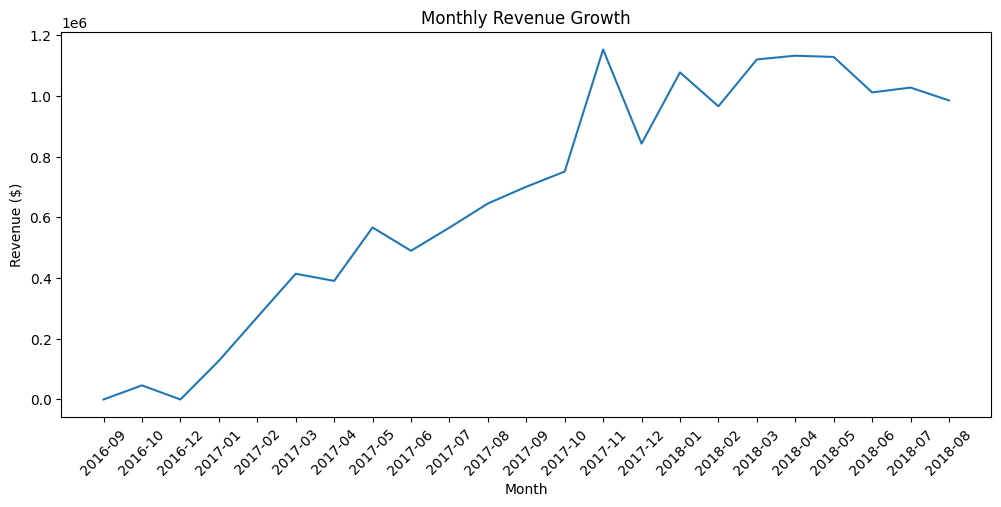

In [201]:
plt.figure(figsize=(12,5))

plt.plot(
    monthly_sales["month"].astype(str),
    monthly_sales["revenue"]
)

plt.xticks(rotation=45)

plt.title(
    "Monthly Revenue Growth"
)

plt.xlabel(
    "Month"
)

plt.ylabel(
    "Revenue ($)"
)

plt.savefig(
    "../visuals/revenue_growth.png",
    bbox_inches="tight"
)

plt.show()

Revenue increased significantly from 2017 onwards, showing strong customer adoption and marketplace growth.

### Top Product Categories

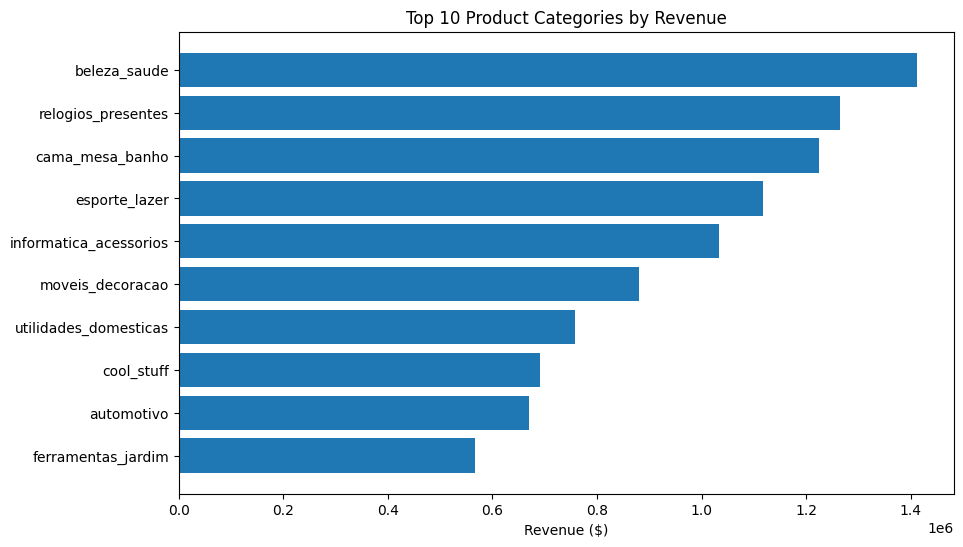

In [202]:
plt.figure(figsize=(10,6))

plt.barh(
    top_categories.index,
    top_categories["revenue"]
)

plt.title(
    "Top 10 Product Categories by Revenue"
)

plt.xlabel(
    "Revenue ($)"
)

plt.gca().invert_yaxis()

plt.savefig(
    "../visuals/top_product_categories_by_revenue.png",
    bbox_inches="tight"
)

plt.show()


Revenue is concentrated among a small number of categories, with health & beauty, watches, and home products being the strongest contributors.

### Top Customers

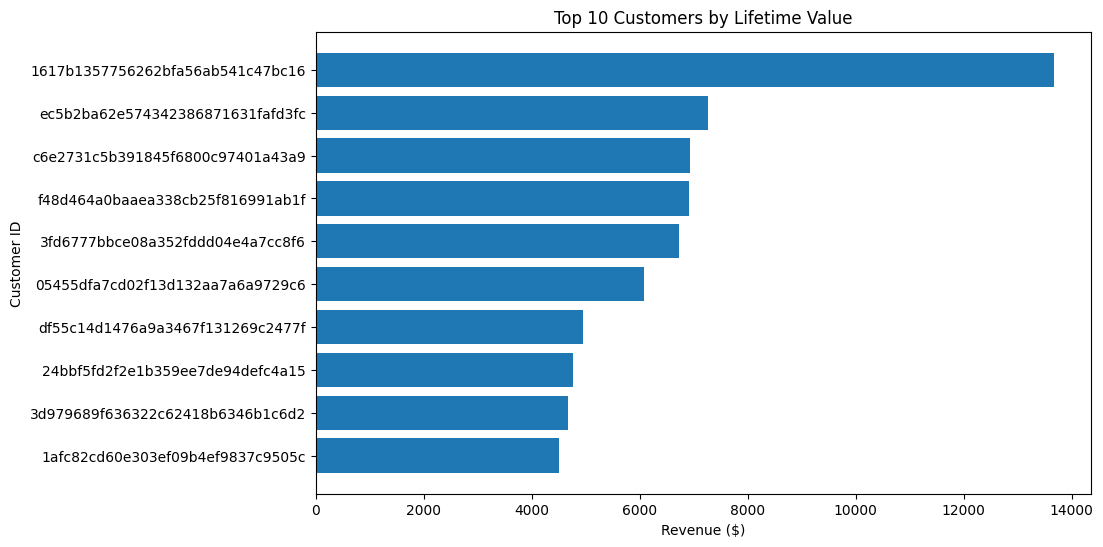

In [203]:
top_customers = (
    customer_rank
    .head(10)
    .sort_values(
        "total_sale_value",
        ascending=True
    )
)

plt.figure(figsize=(10,6))

plt.barh(
    top_customers["customer_id"],
    top_customers["total_sale_value"]
)

plt.title(
    "Top 10 Customers by Lifetime Value"
)

plt.xlabel(
    "Revenue ($)"
)

plt.ylabel(
    "Customer ID"
)

plt.savefig(
    "../visuals/top_customers_by_lifetime_value.png",
    bbox_inches="tight"
)

plt.show()


A small number of customers contribute significantly higher revenue than the average customer. This indicates strong customer value concentration and highlights the importance of retaining high-value customers.

### Customer Revenue Concentration (Deciles)

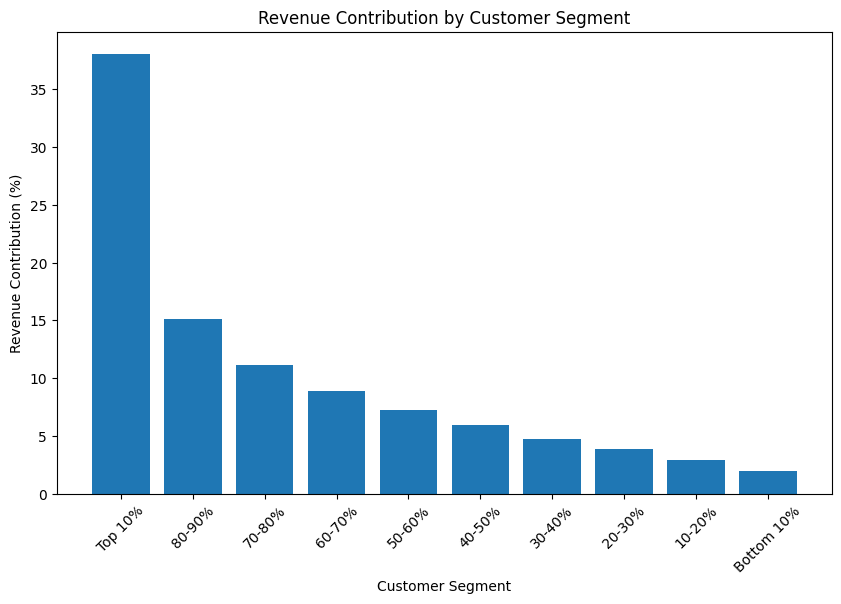

In [204]:
plt.figure(figsize=(10,6))

plt.bar(
    decile_revenue["customer_segment"],
    decile_revenue["revenue_percentage"]
)

plt.xticks(
    rotation=45
)

plt.title(
    "Revenue Contribution by Customer Segment"
)

plt.xlabel(
    "Customer Segment"
)

plt.ylabel(
    "Revenue Contribution (%)"
)

plt.savefig(
    "../visuals/customer_revenue_concentration.png",
    bbox_inches="tight"
)

plt.show()

The top 10% of customers generate approximately 38% of total revenue, demonstrating a strong Pareto effect where a small customer segment drives a large portion of business value.

### Delivery Performance

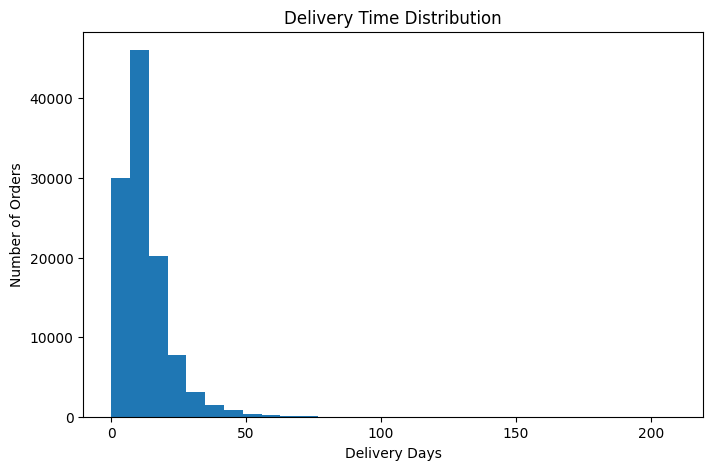

In [205]:
plt.figure(figsize=(8,5))

plt.hist(
    fact_sales["delivery_days"],
    bins=30
)

plt.title(
    "Delivery Time Distribution"
)

plt.xlabel(
    "Delivery Days"
)

plt.ylabel(
    "Number of Orders"
)

plt.savefig(
    "../visuals/delivery_time_distribution.png",
    bbox_inches="tight"
)

plt.show()

Average delivery time is approximately 12 days, but delivery times vary significantly across orders.

### Review Score vs Revenue

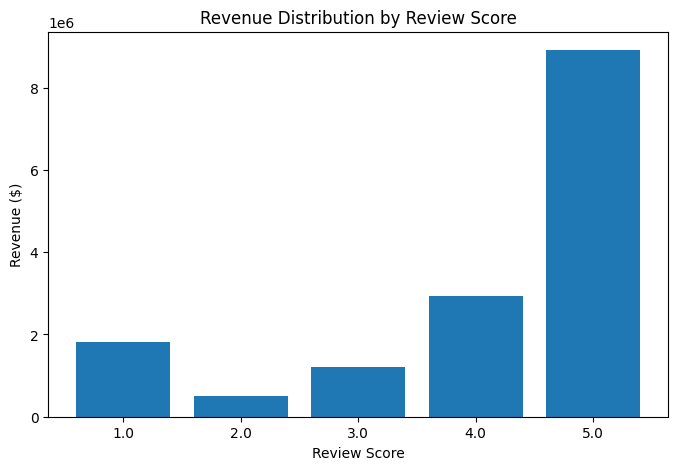

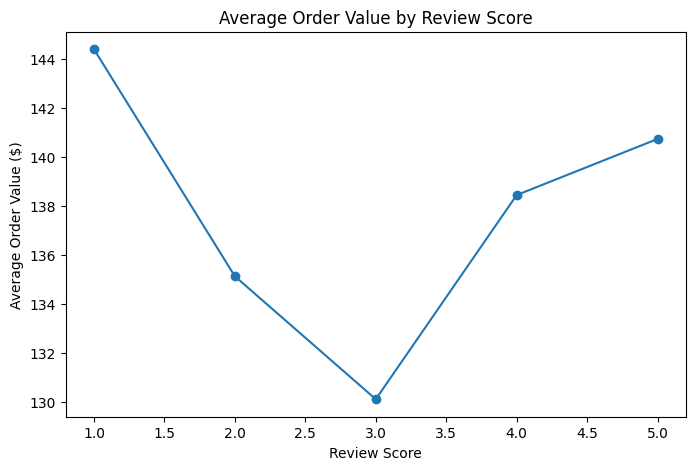

In [206]:
# Revenue distribution by review score
plt.figure(figsize=(8,5))

plt.bar(
    review_analysis.index.astype(str),
    review_analysis["revenue"]
)

plt.title(
    "Revenue Distribution by Review Score"
)

plt.xlabel(
    "Review Score"
)

plt.ylabel(
    "Revenue ($)"
)
plt.savefig(
    "../visuals/revenue_by_review_score.png",
    bbox_inches="tight"
)

# Average order value by review score:
plt.show()

plt.figure(figsize=(8,5))

plt.plot(
    review_analysis.index,
    review_analysis["average_order_value"],
    marker="o"
)

plt.title(
    "Average Order Value by Review Score"
)

plt.xlabel(
    "Review Score"
)

plt.ylabel(
    "Average Order Value ($)"
)

plt.savefig(
    "../visuals/average_order_value_by_review_score.png",
    bbox_inches="tight"
)

plt.show()

Revenue is distributed across different review scores, suggesting customer satisfaction does not directly determine purchasing value. High revenue can occur across various satisfaction levels.

### Seller Performance

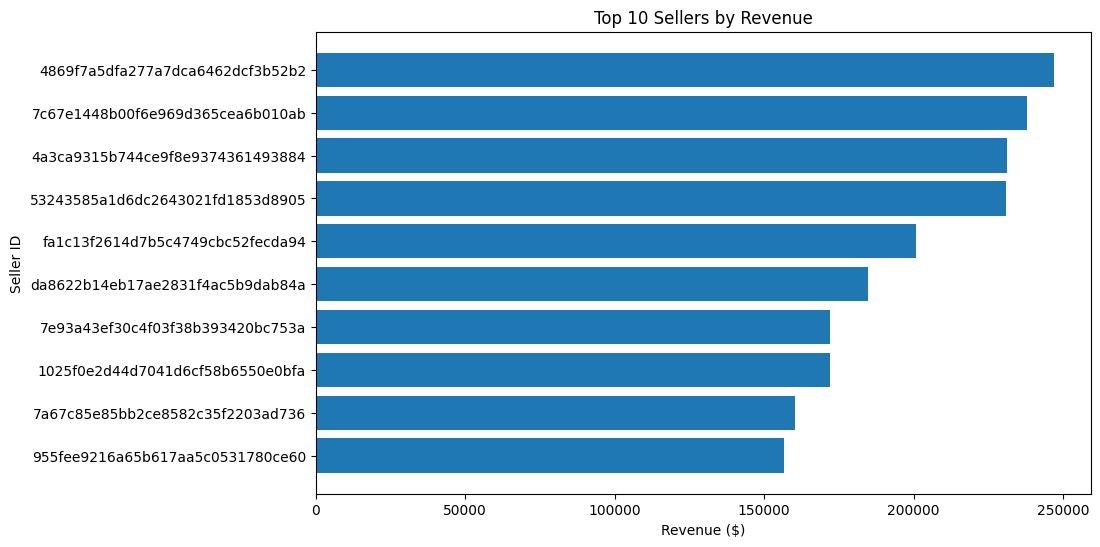

In [207]:
top_sellers = (
    seller_performance
    .sort_values(
        "revenue",
        ascending=True
    )
)

plt.figure(figsize=(10,6))

plt.barh(
    top_sellers.index,
    top_sellers["revenue"]
)

plt.title(
    "Top 10 Sellers by Revenue"
)

plt.xlabel(
    "Revenue ($)"
)

plt.ylabel(
    "Seller ID"
)

plt.savefig(
    "../visuals/top_sellers_by_revenue.png",
    bbox_inches="tight"
)

plt.show()